# Quantum implementation - Variational Quantum Classifier (VQC)

References:
* https://arxiv.org/pdf/2505.17756
* https://arxiv.org/pdf/1804.11326
* Exploring Quantum Machine Learning with Meltem Tolunay: Qiskit Summer School 2024: https://youtu.be/ChPLYpUzsY4
* Quantum Machine Learning Tutorial: https://qml-tutorial.github.io/

Qiskit Machine Learning 0.8.3 libraray (not compatible with Qiskit 2.0,  downgrades Qiskit to 1.4.3 during installation) [Optional]
* https://qiskit-community.github.io/qiskit-machine-learning/tutorials/02a_training_a_quantum_model_on_a_real_dataset.html

Installation:\
!pip install qiskit\
!pip install qiskit-ibm-runtime\
!pip install qiskit[visualization]\
!pip install qiskit-aer\
!pip install qiskit-machine-learning\
!pip install 'qiskit-machine-learning[torch]'\
!pip install 'qiskit-machine-learning[sparse]'

In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.datasets import make_moons
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from qiskit.circuit.library import zz_feature_map, ZZFeatureMap, real_amplitudes, pauli_feature_map
from qiskit.circuit.library import RealAmplitudes
from qiskit.result import QuasiDistribution
import numpy as np

In [2]:
# 1. Fetch Banknote Authentication dataset (4 features, 2 classes)
features, labels = fetch_openml(name="banknote-authentication", version=1, return_X_y=True, as_frame=False, parser="auto")

# Extract exactly 120 samples. We put the "leftovers" into dummy variables (_, _)
features_small, _, labels_small, _ = train_test_split(
    features, 
    labels, 
    train_size=200,     # The exact number of samples you want to keep
    random_state=42,    # Ensures you get the exact same 150 rows every time you run the cell
    stratify=labels     # CRITICAL: Ensures the balance of genuine vs forged is maintained
)

print(f"Original dataset size: {features.shape[0]}")
print(f"New dataset size: {features_small.shape[0]}")

# Check the balance of the classes in your new tiny dataset
import numpy as np
unique, counts = np.unique(labels_small, return_counts=True)
print(f"Class distribution in the 120 samples: {dict(zip(unique, counts))}")

# Convert string labels ('1', '2' or similar) to integers if necessary
labels = labels.astype(int) 
# Note: Banknote classes are 1 (genuine) and 2 (forged). Let's map them to 0 and 1.
if set(labels) == {1, 2}:
    labels = labels - 1

# 2. Normalize features to [0, 1] for the quantum feature map
features = MinMaxScaler().fit_transform(features)

# 3. Split into train and test sets
#train_features, test_features, train_labels, test_labels = train_test_split(
#    features, labels, train_size=0.8, random_state=123
#)

# Now split your NEW 120-sample dataset into train and test sets
train_features, test_features, train_labels, test_labels = train_test_split(
    features_small, labels_small, train_size=0.8, random_state=123
)

num_features = features.shape[1] # This will evaluate to 4
print(f"Number of features: {num_features}")

Original dataset size: 1372
New dataset size: 200
Class distribution in the 120 samples: {'1': np.int64(111), '2': np.int64(89)}
Number of features: 4


In [3]:
# #Iris dataset
# #Don't run this cell if you want to use banknote dataset

# from sklearn.datasets import load_iris
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import train_test_split

# iris = load_iris()

# features = iris.data
# labels = iris.target

# mask = labels != 2

# features_binary = features[mask] #we filter the labels, so the problem becomes binary
# labels_binary = labels[mask]

# features_binary = MinMaxScaler().fit_transform(features_binary)

# train_features, test_features, train_labels, test_labels = train_test_split(
#     features_binary,
#     labels_binary,
#     train_size=0.8,
#     random_state=123,
#     stratify=labels_binary
# )

# num_features = features_binary.shape[1]

# print(features_binary.shape)
# print(set(labels_binary))

## Feature maps (Data Encoding)
https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding

## Encoding with built-in feature maps
### We need to construct feature map - which will store our classical data as gate parameters:
Some functions from https://docs.quantum.ibm.com/api/qiskit/circuit_library :

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.zz_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.z_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.efficient_su2

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.real_amplitudes

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.pauli_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.pauli_two_design

Fully customizable parametrized circuit:
https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.ParameterVector 

## Here we create feature map ecoding our data features $\vec{x}=(x[0], x[1], ...)$
See https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding

C:\Users\kacpe\AppData\Local\Temp\ipykernel_20648\219689029.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)


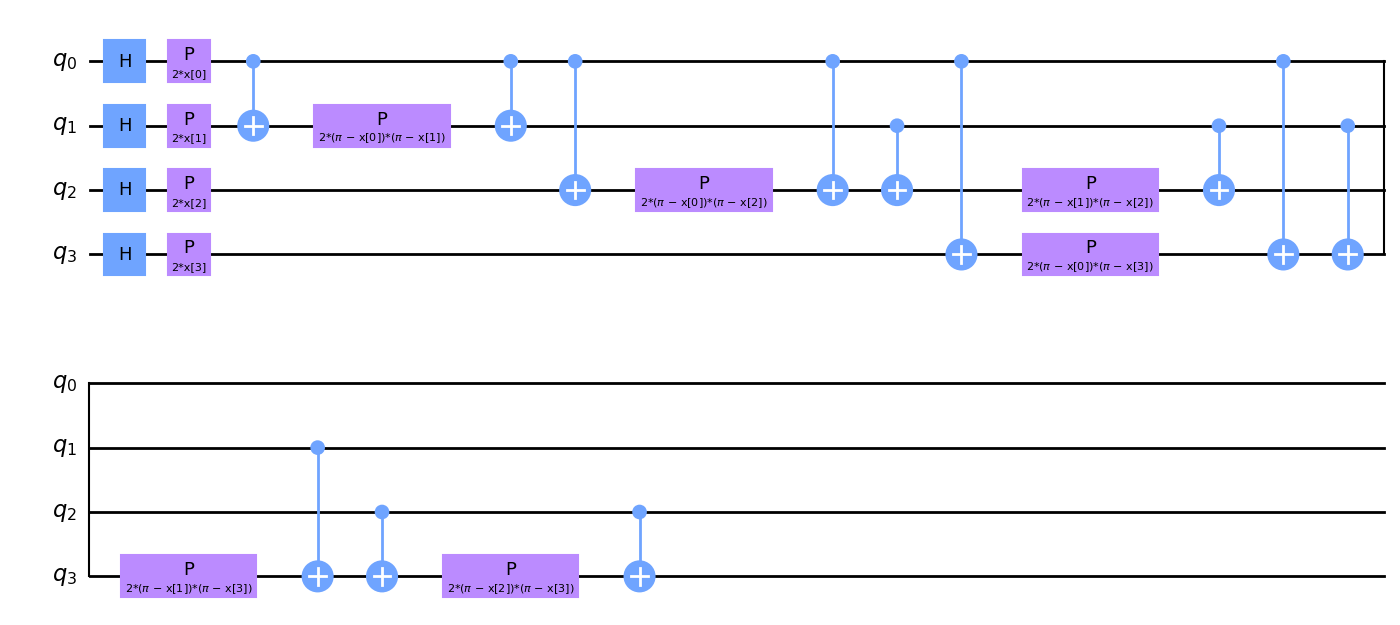

4

ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3])])

In [4]:
num_features = features.shape[1]
## ZZFeatureMap
#data_map = lambda x: np.pi-x[0]*x[0] # note: input is an array
#feature_map = ZZFeatureMap(feature_dimension=num_features, data_map_func=data_map, reps=1)
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
#feature_map = pauli_feature_map(4, paulis=["Z", "YY"], entanglement="full")
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)

display(feature_map.decompose().draw(output="mpl", style="clifford", fold=20))
display(feature_map.num_parameters)
display(feature_map.parameters)

### Now let's create the anzats - being our quantum neural network (QNN) which we need to train with set of optimization parameters $\vec\theta=(\theta[0], \theta[1], ...)$. Again we can use various quantum circuits(VQC):
https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/qvc-qnn

Some functions from https://docs.quantum.ibm.com/api/qiskit/circuit_library :

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.zz_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.z_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.efficient_su2

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.real_amplitudes

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.pauli_feature_map

https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.pauli_two_design

In [5]:
# I tried different approaches, but I didn't get results better than 56%

ansatz1 = RealAmplitudes(num_qubits=num_features, reps=1)
ansatz1.decompose().draw(output="mpl", style="clifford", fold=20)

ansatz2 = RealAmplitudes(
    num_qubits=num_features,
    reps=2,
    entanglement="full"
)

from qiskit.circuit.library import EfficientSU2

ansatz3 = EfficientSU2(
    num_qubits=num_features,
    reps=1
)

C:\Users\kacpe\AppData\Local\Temp\ipykernel_20648\1193074533.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz1 = RealAmplitudes(num_qubits=num_features, reps=1)
C:\Users\kacpe\AppData\Local\Temp\ipykernel_20648\1193074533.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz2 = RealAmplitudes(
C:\Users\kacpe\AppData\Local\Temp\ipykernel_20648\1193074533.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz3 = EfficientSU2(


### Now we compose full circuit based on features encoding encoding and ansatz

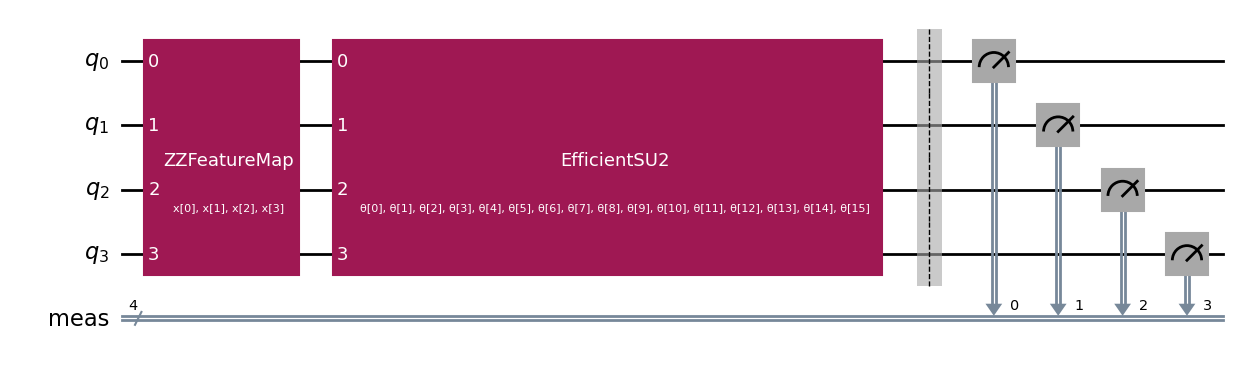

In [6]:
from qiskit import QuantumCircuit

circuit1 = QuantumCircuit(num_features)
circuit1.compose(feature_map, inplace=True)
circuit1.compose(ansatz1, inplace=True)
circuit1.measure_all()

circuit2 = QuantumCircuit(num_features)
circuit2.compose(feature_map, inplace=True)
circuit2.compose(ansatz2, inplace=True)
circuit2.measure_all()


circuit3 = QuantumCircuit(num_features)
circuit3.compose(feature_map, inplace=True)
circuit3.compose(ansatz3, inplace=True)
circuit3.measure_all()

circuit3.draw('mpl')

In [7]:
from qiskit.transpiler import generate_preset_pass_manager
 
pm = generate_preset_pass_manager(optimization_level=3)
isa_circuit1 = pm.run(circuit1)
isa_circuit2 = pm.run(circuit2)
isa_circuit3 = pm.run(circuit3)

In [8]:
import numpy as np
num_thetas1 = circuit1.num_parameters - circuit1.num_qubits
initial_thetas1 = 0.5* np.pi * np.random.random(num_thetas1)
print(initial_thetas1)

num_thetas2 = circuit2.num_parameters - circuit2.num_qubits
initial_thetas2 = 0.5* np.pi * np.random.random(num_thetas2)
print(initial_thetas2)

num_thetas3 = circuit3.num_parameters - circuit3.num_qubits
initial_thetas3 = 0.5* np.pi * np.random.random(num_thetas3)
print(initial_thetas3)

[1.00263593 0.57245742 0.4491686  0.46620752 1.53094958 0.89619913
 0.15041751 0.34771969]
[0.14306719 1.2340661  0.73135345 0.15367143 0.47364423 1.24788527
 0.47464661 1.2476246  0.2224435  0.55364159 0.79671565 1.1053608 ]
[1.13984839 0.91343668 0.55327411 0.55295497 0.64880429 0.32390315
 0.90646938 0.98126034 0.53341922 0.38722338 1.23116261 1.43868887
 0.15330872 0.15972341 0.89656817 1.37242514]


In [9]:
np.shape(train_features)

(160, 4)

In [10]:
#Observable based approach. I got even worse results and accuracy compared to probability based approach

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
import numpy as np

circuit_no_measure = QuantumCircuit(num_features)
circuit_no_measure.compose(feature_map, inplace=True)
circuit_no_measure.compose(ansatz1, inplace=True) # put different ansatz here

pm = generate_preset_pass_manager(optimization_level=3)
isa_circuit = pm.run(circuit_no_measure) # no measurement

observable = SparsePauliOp("Z" * num_features)

estimator = StatevectorEstimator()

cost_values = []

def estimator_cost_function(thetas, circuit, estimator):
    cost = 0.0
    eps = 1e-10

    for point_number, X in enumerate(train_features):
        params = np.concatenate((X, thetas))

        pub = (circuit, observable, params)
        job = estimator.run([pub])

        expectation = float(job.result()[0].data.evs)

        p_0 = (1.0 + expectation) / 2.0
        p_1 = 1.0 - p_0

        label = int(train_labels[point_number])

        if label == 0:
            cost -= np.log(p_0 + eps)
        else:
            cost -= np.log(p_1 + eps)

    avg_cost = cost / len(train_features)

    print(f"Current Avg Cost: {avg_cost:.4f}")
    cost_values.append(avg_cost)

    return avg_cost

In [11]:
from qiskit.primitives import StatevectorSampler
from scipy.optimize import minimize
import numpy as np

# We assume train_features and train_labels are already defined globally
cost_values = []

def probability_cost_function(thetas, circuit, sampler, cost_values):
    cost = 0
    num_shots = 1000
    eps = 1e-10 # Small value to prevent taking log(0)
    
    for point_number, X in enumerate(train_features):
        # 1. Combine feature values and trainable parameters
        params = np.concatenate((X, thetas))
        
        # 2. Create the V2 PUB (Primitive Unified Bloc)
        pub = (circuit, params)
        
        # 3. Run the sampler (Note: using the sampler passed in args is faster 
        # than recreating StatevectorSampler() inside the loop)
        job = sampler.run([pub], shots=num_shots)
        
        # 4. Extract counts
        counts = job.result()[0].data.meas.get_counts()
        
        # 5. Convert binary string keys (like '0000') to integer keys (like 0) and normalize
        # int(k, 2) turns base-2 string into an integer.
        counts_normalized = {int(k, 2): v / num_shots for k, v in counts.items()}
        
        # 6. Get probability of state 0 (which corresponds to |00...0>)
        p_0 = counts_normalized.get(0, 0.0)
        p_1 = 1.0 - p_0
        
        # 7. Binary Cross-Entropy logic
        label = train_labels[point_number]
        if label == 0:
            cost -= np.log(p_0 + eps)
        else:
            cost -= np.log(p_1 + eps)
            
    # Average the cost over all data points
    
    avg_cost = cost / len(train_features)

    print(f"Current Avg Cost: {avg_cost:.4f}")
    cost_values.append(avg_cost)

    return avg_cost
    

In [12]:
# Run the optimizer just like before
cost_values1 = []
cost_values2 = []
cost_values3 = []

sampler_v2 = StatevectorSampler()
result1 = minimize(
    probability_cost_function,
    initial_thetas1,
    args=(isa_circuit1, sampler_v2, cost_values1),
    method="COBYLA",
    tol=1e-2
)
print("2")

result2 = minimize(
    probability_cost_function,
    initial_thetas2,
    args=(isa_circuit2, sampler_v2, cost_values2),
    method="COBYLA",
    tol=1e-2
)
print("3")

result3 = minimize(
    probability_cost_function,
    initial_thetas3,
    args=(isa_circuit3, sampler_v2, cost_values3),
    method="COBYLA",
    tol=1e-2
)
print("end")

# # Observable-based approach
# sampler_v2 = StatevectorSampler()
# result = minimize(
#     estimator_cost_function,
#     initial_thetas,
#     args=(isa_circuit, estimator),
#     method="COBYLA",
#     tol=1e-2
# )

Current Avg Cost: 0.0700
Current Avg Cost: 0.0706
Current Avg Cost: 0.0683
Current Avg Cost: 0.0732
Current Avg Cost: 0.0750
Current Avg Cost: 0.0681
Current Avg Cost: 0.0663
Current Avg Cost: 0.0658
Current Avg Cost: 0.0662
Current Avg Cost: 0.0579
Current Avg Cost: 0.0528
Current Avg Cost: 0.0576
Current Avg Cost: 0.0566
Current Avg Cost: 0.0518
Current Avg Cost: 0.0543
Current Avg Cost: 0.0615
Current Avg Cost: 0.0561
Current Avg Cost: 0.0538
Current Avg Cost: 0.0512
Current Avg Cost: 0.0577
Current Avg Cost: 0.0543
Current Avg Cost: 0.0555
Current Avg Cost: 0.0544
Current Avg Cost: 0.0527
Current Avg Cost: 0.0515
Current Avg Cost: 0.0514
Current Avg Cost: 0.0540
Current Avg Cost: 0.0520
Current Avg Cost: 0.0504
Current Avg Cost: 0.0511
Current Avg Cost: 0.0505
Current Avg Cost: 0.0511
Current Avg Cost: 0.0508
Current Avg Cost: 0.0507
Current Avg Cost: 0.0513
Current Avg Cost: 0.0511
Current Avg Cost: 0.0510
Current Avg Cost: 0.0511
Current Avg Cost: 0.0515
Current Avg Cost: 0.0503


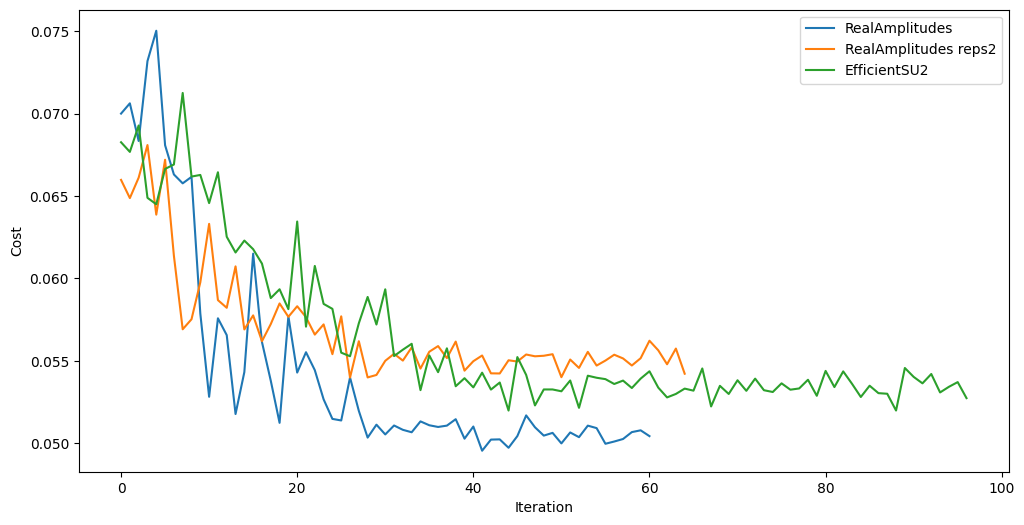

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cost_values1, label = 'RealAmplitudes')
plt.plot(cost_values2, label = 'RealAmplitudes reps2')
plt.plot(cost_values3, label = 'EfficientSU2')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [20]:
import numpy as np

def classify(features, thetas, circuit, sampler):
    num_shots = 10000
    params = np.concatenate((features, thetas))
    
    # Create the PUB and run using the provided sampler
    pub = (circuit, params)
    job = sampler.run([pub], shots=num_shots)
    counts = job.result()[0].data.meas.get_counts()
        
    # Convert binary string keys (e.g., '0000') to integer keys and normalize
    counts_normalized = {int(k, 2): v / num_shots for k, v in counts.items()}

    # For binary classification, we just check the probability of state 0
    p_0 = counts_normalized.get(0, 0.0)
    
    # If the probability of state 0 is greater than 50%, classify as 0. Otherwise, 1.
    if p_0 > 0.5:
        return 0
    else:
        return 1

In [22]:
from qiskit.primitives import StatevectorSampler

# Initialize the sampler ONCE to save time
sampler_v2 = StatevectorSampler()

# --- Evaluate Training Set ---
correct_classifications = 0

for features, true_label in zip(train_features, train_labels):
    # Pass the pre-initialized sampler and the trained parameters (result.x)
    y = classify(features, result1.x, isa_circuit1, sampler_v2) #Change here for different circuits
    
    if int(y) == int(true_label):
        correct_classifications += 1

train_score = correct_classifications / len(train_features)
print(f"Training Accuracy: {train_score:.2%}")


# --- Evaluate Testing Set ---
correct_classifications = 0

for features, true_label in zip(test_features, test_labels):
    y = classify(features, result1.x, isa_circuit1, sampler_v2)
    
    if int(y) == int(true_label):
        correct_classifications += 1

test_score = correct_classifications / len(test_features)
print(f"Testing Accuracy: {test_score:.2%}")

Training Accuracy: 56.25%
Testing Accuracy: 52.50%


### --------------------------------------------------------------------------

### Here we use VQC alghoritm from qiskit_machine_learning.algorithms library

### Exercises:
1. **Architecture Exploration:** Experiment with different types of feature maps (data encoding strategies e.g. AngleEncoding, ZZFeatureMap, etc) and various parameterized *ansätze* (RealAmplitudes, EfficientSU2, etc.). Compare how they affect the model's accuracy and training time.
2. **Cost Function Comparison:** Implement and compare two different types of cost functions:
    * **Probability-based:** Calculate the loss based on the probability of measuring specific states (e.g., $|00\dots0\rangle$ or Even/Odd states).
    * **Observable-based:** Calculate the loss based on the expectation value of a global observable (e.g., $Z \otimes Z \dots \otimes Z$).
3. **The Iris Dataset:** Adapt your Variational Quantum Classifier (VQC) pipeline to predict the classes of the standard [Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html). *(Hint: The Iris dataset contains 3 classes. You can either filter the data to make it a binary classification problem or attempt to upgrade your model to handle multi-class classification!)*

### Homework Reading:
1. Get familiar with Qiskit Machine Learning (0.9) tutorial for more advanced problmes: \
https://qiskit-community.github.io/qiskit-machine-learning/tutorials/index.html
2. Read recent news about how IBM will plan to build the world's first large-scale, fault-tolerant quantum computer https://www.ibm.com/quantum/blog/large-scale-ftqc and corresponding article "Tour de gross: A modular quantum computer based on bivariate bicycle codes" https://www.arxiv.org/abs/2506.03094
 